# <font color="red"> **Parte 2: Visualización avanzada de datos**

En la clase anterior se exploraron algunas herramientas de visualización avanzada de datos utilizando Matplotlib, como *histogramas y gráficos de caja y bigotes*, que permiten analizar la distribución y variabilidad de los datos. En esta segunda clase se introducirán nuevas técnicas de visualización que permiten representar información más compleja y multidimensional, como **mapas de calor, gráficos de contorno y visualizaciones tridimensionales**.

In [39]:
#Vamos a importar las librerias necesarias para este notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

-------

## <font color="darkblue"> **Mapas de calor (heatmaps)**

Los **mapas de calor** (heatmaps) son un tipo de visualización que permite **representar la magnitud de los valores de una variable mediante colores en una matriz o en un espacio bidimensional**. En este tipo de gráfico, cada celda o punto del plano se colorea de acuerdo con el valor de la variable que se desea representar, utilizando una escala de colores que facilita la identificación de patrones, gradientes y zonas con valores altos o bajos. 

<img src="heatmap.png" width="450" style="margin-left: 200px;">

#### <font color= "darkolivegreen"> **¿Para qué nos sirven?**

Los mapas de calor son especialmente *útiles para analizar datos espaciales, matrices de correlación o campos continuos, ya que permiten observar rápidamente la distribución de los valores en una superficie*. En el análisis científico y ambiental, por ejemplo, pueden emplearse para visualizar campos de temperatura, precipitación o humedad sobre una región geográfica. 

#### <font color="darkolivegreen"> **¿Cómo creamos un heatmap?**
En Matplotlib, los **heatmaps** se suelen construir con funciones como `imshow()` o `pcolormesh()`, y normalmente se acompañan de una barra de colores (colorbar) que muestra la relación entre los colores y los valores numéricos.


####  <font color="darkorange"> **Ejemplo 1: `imshow()`**


<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html>

In [40]:
#Comúnmente, los heatmaps se crean con matrices 2D

#Vamos a crear un conjunto de datos que supondremos que son anomalías en el campo magnético de la tierra, medidos desde diversos
# puntos de México

#Creamos datos que simulen las mediciones para cada estacion
anomalias = np.array([
[-5,-10,-15,-10,-5], #Cada fila representa la latitud de cada estación
[-20,-30,-20,-10,10], #Cada columna la longitud
[-30,-50,-30,-15,25],
[-10,-20,-30,-20,-10],
[-10,-15,-10,-5,0]
])

#Vamos a ver la forma del arreglo
anomalias.shape

(5, 5)

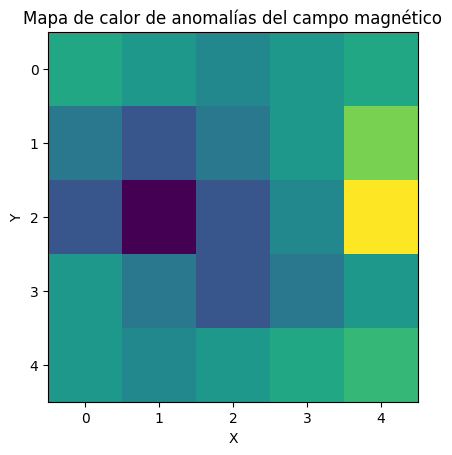

In [41]:
# Graficar heatmap: imshow()

plt.imshow(anomalias) #Datos

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")

plt.show() #¿Cómo identifico los valores de cada anomalía?

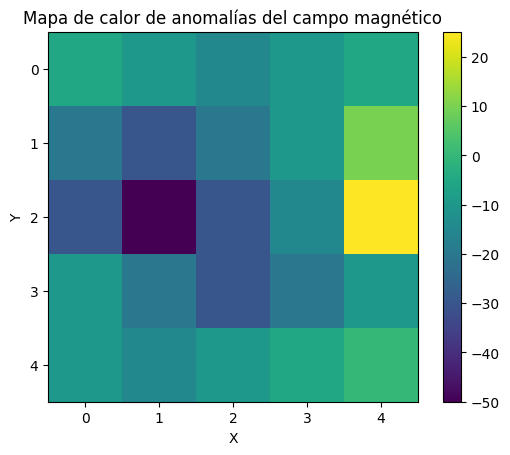

In [42]:
#Agregando barra de color

plt.imshow(anomalias) #Datos

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar() #Por default, el ticks superior de la barra es el valor máximo y el inferior el mínimo
plt.show()

#### <font color="darkblue"> **Personalización**

* Colormaps (<https://matplotlib.org/stable/users/explain/colors/colormaps.html>)

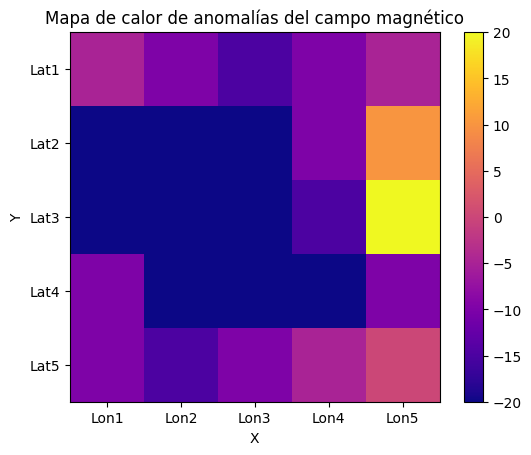

In [43]:
#Queremos cambiar de colormap, la simetría de la barra y personalizar las etiquetas

#Para que el colorbar sea simétrico es necesario definir los mismos límites pero con signo contrario
valor_minimo=-20
valor_maximo=20

#Definimos el nombre de las etiquetas
etiquetas_x=["Lon1","Lon2","Lon3","Lon4","Lon5"]
etiquetas_y=["Lat1","Lat2","Lat3","Lat4","Lat5"]

plt.imshow(anomalias,
           cmap="plasma", #Cambiar color map
           vmin=valor_minimo, #Límite mínimo de la barra
           vmax=valor_maximo #Límite máximo de la barra
          )

#Usamos ticks para modificar las etiquetas de los ejes
plt.xticks(np.arange(5), etiquetas_x)
plt.yticks(np.arange(5), etiquetas_y)


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar()
plt.show()

0 0
0 1
0 2
0 3
0 4
1 0
1 1
1 2
1 3
1 4
2 0
2 1
2 2
2 3
2 4
3 0
3 1
3 2
3 3
3 4
4 0
4 1
4 2
4 3
4 4


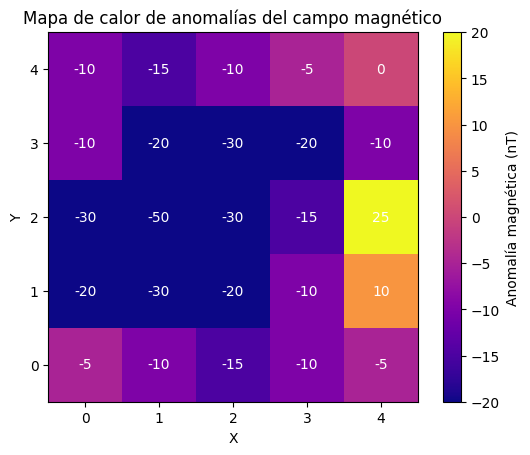

In [44]:
#Más personalizaciones

plt.imshow(anomalias,
           cmap="plasma", 
           vmin=valor_minimo, 
           vmax=valor_maximo,
           origin="lower", #Controla dónde empieza la matriz, por default "upper"
           interpolation="nearest"  #Suaviza los pixeles ("nearest","bilinear",bicubic")
          )

#Para agregar los valores de las anomalías
for i in range(anomalias.shape[0]):
    
    for j in range(anomalias.shape[1]):
        print(i,j)
        plt.text(j, i, anomalias[i,j],
                 ha="center", #Alineación horizontal
                 va="center", #Alineación vertical
                 color="white")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Mapa de calor de anomalías del campo magnético")
plt.colorbar(label="Anomalía magnética (nT)") #Podemos agregar etiqueta a la barra
plt.show()

####  <font color="darkorange"> **Ejemplo 2: `pcolormesh()`**

La función `pcolormesh()` de Matplotlib también sirve para hacer mapas de calor, pero a diferencia de `imshow()` es mucho más usada en Ciencias de la Tierra porque permite trabajar con coordenadas reales (latitud, longitud, distancia, etc.).

Comúnmente, cuando se trabaja con datos de NetCDF o xarray, casi siempre se usa `pcolormesh()`.

In [45]:
#Retomando el ejemplo anterior

#Paso 1: Definimos las coordenadas de nuestros datos (latitud,longitud)

x = np.linspace(-119,-110,5) #Longitud
y = np.linspace(14,20,5) #Latitud


#Paso 2: Transformar los datos a matriz 2D

Para poder graficar algo en 2D, necesitamos un arreglo de 2D. Para generar un arreglo 2D podemos utilizar la función de numpy `meshgrid`.

La función `np.meshgrid` en NumPy se utiliza para crear matrices de coordenadas a partir de matrices unidimensionales, lo que es particularmente útil para generar mallas de puntos en 2D para su posterior uso en gráficos tridimensionales, interpolación de datos, y cálculos vectoriales.

Cuando se aplica np.meshgrid a dos o más arrays unidimensionales, devuelve matrices multidimensionales donde cada dimensión representa un conjunto de coordenadas. Por ejemplo, si tienes dos arrays unidimensionales $x$ y $y$, `np.meshgrid(x, y)` generará dos matrices bidimensionales, una correspondiente a las coordenadas y otra a las coordenadas.

Las salidas de `np.meshgrid` son útiles para operaciones que involucran manipulación de coordenadas, como trazado de gráficos en 3D, evaluación de funciones en una cuadrícula de puntos, interpolación de datos, cálculos de derivadas parciales y más.

En resumen, `np.meshgrid` es una función fundamental para la creación de mallas de puntos en 2D a partir de arrays unidimensionales, lo que facilita la representación visual de datos y cálculos vectoriales en el espacio bidimensional.

In [46]:
#Arreglo 2D
Lon,Lat=np.meshgrid(x,y) #Se utiliza para transformar vectores unidimensionales de coordenadas en matrices multidimensionales

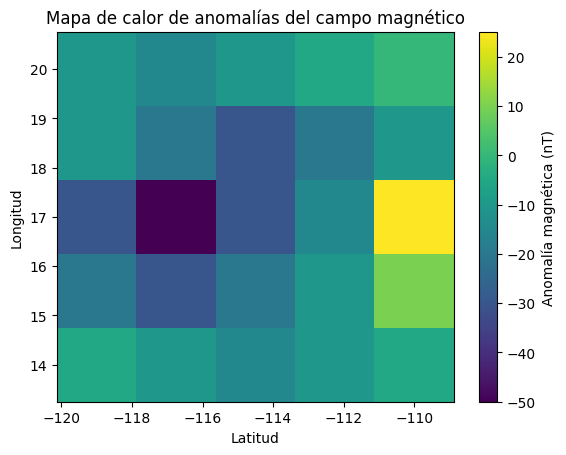

In [47]:
#Paso 3: Graficar el mapa de calor

plt.pcolormesh(Lon,Lat,anomalias) #Tengo que colocar las coordenadas de mis datos (x,y) y los datos a graficar

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

plt.show()

#### <font color="darkblue"> **Personalización**

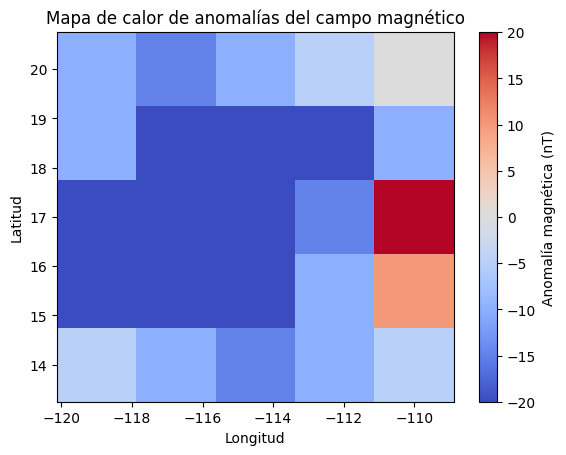

In [48]:
plt.pcolormesh(Lon,Lat,anomalias,
              cmap="coolwarm",  #Colormap diferente
              vmin= -20,        #Valor mínimo
              vmax=20,           #Valor máximo
              shading="auto"     #Controla cómo se dibujan las celdas ("auto"[recomendado], "nearest", "gouraud")
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de anomalías del campo magnético")

plt.show()

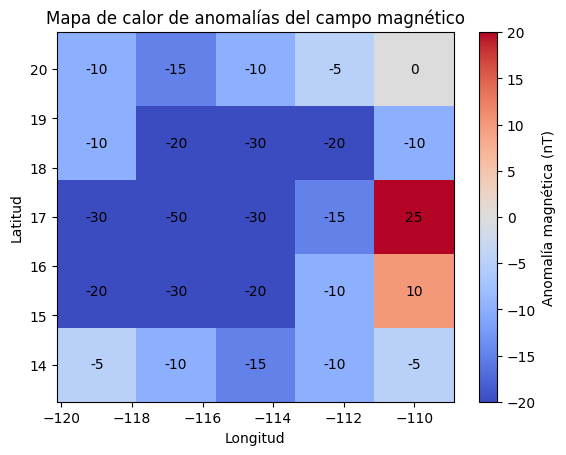

In [49]:
#Quiero agregar los valores exactos de la anomalía para cada cuadrícula
plt.pcolormesh(Lon,Lat,anomalias,
              cmap="coolwarm",  
              vmin= -20,        
              vmax=20,           
              shading="auto"     
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(anomalias.shape[0]):
    for j in range(anomalias.shape[1]):
        plt.text(Lon[i,j], Lat[i,j], anomalias[i,j],
                 ha="center",
                 va="center",
                 color="black")

plt.show()



### <font color="brown"> **Diferencias entre `imshow()` y `pcolormesh()`**

| Característica | `imshow()`                     | `pcolormesh()`                   |
| -------------- | ------------------------------ | -------------------------------- |
| Tipo de datos  | matriz tratada como **imagen** | matriz en **coordenadas reales** |
| Ejes           | usa **índices de la matriz**   | usa **X y Y explícitos**         |
| Velocidad      | **más rápido**                 | un poco **más lento**            |
| Uso típico     | imágenes, matrices             | mapas científicos                |
| Geociencias    | menos usado                    | **muy usado**                    |
| Celdas         | píxeles                        | cuadrículas                      |


### <font color="brown"> **Valores faltantes (NaN) en nuestros datos**

Vamos a conciderar que en nuestros datos existen valores faltantes

In [50]:
#Agregando datos faltantes

anomalias_nan = np.array([
[-5,-10,-15,-10,-5], 
[-20,np.nan,-20,-10,10], 
[-30,-50,-30,-15,25],
[-10,-20,-30,np.nan,np.nan],
[-10,-15,np.nan,-5,0]
])


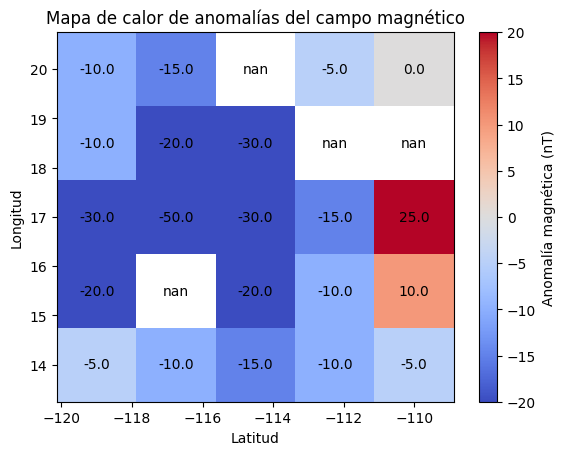

In [51]:
#Vamos a graficar

plt.pcolormesh(Lon,Lat,anomalias_nan,
              cmap="coolwarm",  
              vmin= -20,        
              vmax=20,           
              shading="auto"     
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(anomalias_nan.shape[0]):
    for j in range(anomalias_nan.shape[1]):
        plt.text(Lon[i,j], Lat[i,j], anomalias_nan[i,j],
                 ha="center",
                 va="center",
                 color="black")

plt.show()



#### **¿Cómo trato los `NaN`?**

* Eliminarlos antes de graficar
* Enmascarar los datos

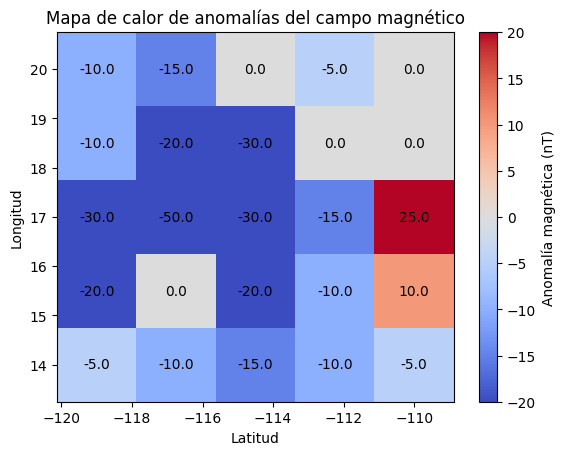

In [52]:
# Eliminar NaN, pero esto no siempre es recomendable porque podrías cambiar el significado físico.
anomalias_sin_nan=np.nan_to_num(anomalias_nan)


plt.pcolormesh(Lon,Lat,anomalias_sin_nan,
              cmap="coolwarm",  
              vmin= -20,        
              vmax=20,           
              shading="auto"     
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(anomalias_sin_nan.shape[0]):
    for j in range(anomalias_sin_nan.shape[1]):
        plt.text(Lon[i,j], Lat[i,j], anomalias_sin_nan[i,j],
                 ha="center",
                 va="center",
                 color="black")

plt.show()

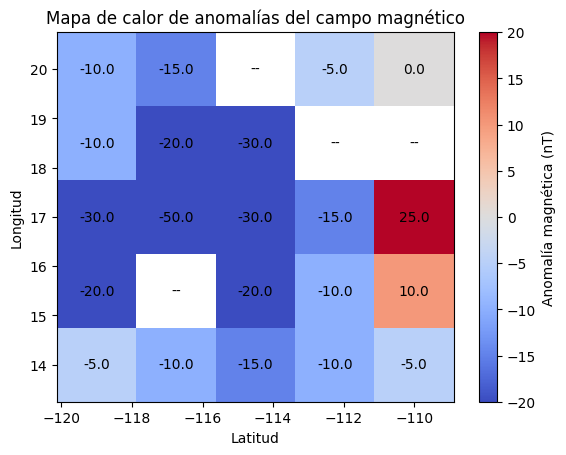

In [53]:
#Enmascarar los datos

datos_mask = np.ma.masked_invalid(anomalias_nan) #Crea un arreglo enmascarado (masked array) 
                                                 #donde todos los valores inválidos se marcan como ocultos o ignorados.


plt.pcolormesh(Lon,Lat,datos_mask,
              cmap="coolwarm",  
              vmin= -20,        
              vmax=20,           
              shading="auto"     
              ) 

plt.colorbar(label="Anomalía magnética (nT)")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title("Mapa de calor de anomalías del campo magnético")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(datos_mask.shape[0]):
    for j in range(datos_mask.shape[1]):
        plt.text(Lon[i,j], Lat[i,j], datos_mask[i,j],
                 ha="center",
                 va="center",
                 color="black")

plt.show()

### <font color="purple"> **Ejercicio 1: Concentración de oxígeno disuelto en un lago**

Crea valores aleatorios de concentración de oxígeno disuelto (mg/L) en 10 niveles diferentes de profundidad y considerando que se obtuvo un valor por mes durante un año. Las concentraciones deben estar entre los rangos de 0 y 9 mg/L .

`Hint: np.random.uniform(inicio,fin,(filas,columnas))`


**1. ¿Qué representa cada fila y cada columna?**

**2. Crea un heatmap con los datos**

In [54]:
#Oxígeno disuelto
oxigeno=np.random.uniform(0,9,(10,12))
oxigeno  #Cada fila representa los datos que cambian en y, en este caso la profundidad, mientras que las columnas son los datos que cambian en 
        # x, en este caso los meses

array([[8.04735417e+00, 7.70590934e+00, 4.28185775e+00, 2.16389263e+00,
        1.55245735e+00, 5.99392877e-01, 3.99261569e+00, 6.82448850e+00,
        6.67226527e+00, 3.10707972e+00, 3.97124110e+00, 1.65699550e+00],
       [3.89078408e+00, 3.13565281e+00, 8.87069732e+00, 1.30793048e+00,
        8.48521865e+00, 4.86344581e+00, 7.72483433e+00, 3.38126740e+00,
        3.12080355e-01, 1.20368439e+00, 8.47714002e+00, 5.01062020e+00],
       [8.45925747e+00, 3.79903850e+00, 5.51892240e-01, 2.80950232e+00,
        2.80993619e-01, 7.48127770e+00, 3.39484733e+00, 1.39219717e+00,
        3.44661587e-01, 7.44943354e+00, 5.71579723e+00, 5.50174847e+00],
       [7.09186892e+00, 8.46446764e+00, 6.82788624e+00, 4.60598419e+00,
        1.13144826e-01, 5.78354222e+00, 4.63037672e+00, 3.94931471e+00,
        2.49161615e+00, 4.91452798e+00, 4.31722579e+00, 2.59981792e+00],
       [3.94703148e+00, 7.99487822e+00, 8.40350280e+00, 8.02152084e+00,
        3.43685271e+00, 7.87479963e-01, 4.25588230e+00, 4.14

In [55]:
#Creando el heatmap
profundidad=np.arange(1,11,1)
meses=np.arange(1,13,1)
#Arreglo 2D
Meses,Profundidad=np.meshgrid(meses,profundidad) #Se utiliza para transformar vectores unidimensionales de coordenadas en matrices multidimensionales

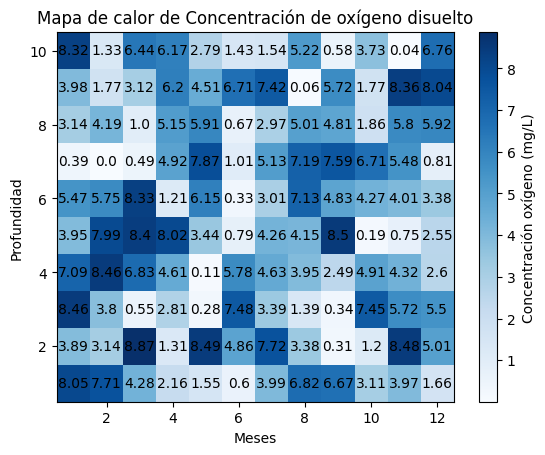

In [56]:
#Quiero agregar los valores exactos de la anomalía para cada cuadrícula
plt.pcolormesh(Meses,Profundidad,oxigeno,
              cmap="Blues",            
              shading="auto"     
              ) 

plt.colorbar(label="Concentración oxígeno (mg/L)")
plt.xlabel("Meses")
plt.ylabel("Profundidad")
plt.title("Mapa de calor de Concentración de oxígeno disuelto")

#Usamos un ciclo for y ocupamos plt.text()
for i in range(oxigeno.shape[0]):
    for j in range(oxigeno.shape[1]):
        plt.text(Meses[i,j], Profundidad[i,j], round(oxigeno[i,j],2),
                 ha="center",
                 va="center",
                 color="black")

plt.show()

--------------------------

## <font color="darkblue">**Gráficos de contorno**

Los **gráficos de contorno** son representaciones gráficas utilizadas para mostrar la distribución de una variable continua en una superficie bidimensional mediante líneas que conectan puntos con el mismo valor, conocidas como líneas de contorno o isolíneas. Estas líneas permiten visualizar cómo cambian los valores de la variable en el espacio y facilitan la identificación de gradientes, máximos, mínimos y patrones espaciales. En algunos casos, los mapas de contorno también pueden incluir relleno de color entre las isolíneas, lo que ayuda a resaltar las variaciones de la variable de manera más clara. 
<p float="left">
  <img src="contour.png" width="43%" />
  <img src="contourfill.png" width="51%" />
</p>


Este tipo de gráfico es ampliamente utilizado en Ciencias de la Tierra para representar campos continuos como temperatura (isotermas), presión atmosférica (isobaras), precipitación (isoyeta), elevación del terreno (curvas de nivel)., salinidad del océano (isohalina), profundidad marina (isobata) ........ y más

#### <font color="darkolivegreen"> **¿Cómo grafico mapas de contorno?**
En Matplotlib, los mapas de contorno se pueden generar mediante funciones como `contour()` y `contourf ()`, que permiten dibujar líneas de contorno o mapas con relleno de color a partir de datos organizados en una malla bidimensional.

#### <font color="darkorange"> **Ejemplo 1: `plt.contour()`**
<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html>

In [22]:
#Vamos a generar mapas de curvas de nivel

# Coordenadas de la zona
x=np.linspace(-119,-110,7) #Longitud
y = np.linspace(14,20,7) #Latitud

#Necesitamos crear nuestra arreglo 2D
Lon, Lat = np.meshgrid(x,y)

# Elevación del terreno 
Z = np.array([
[5,7,9,10,9,7,5],
[7,12,16,18,16,12,7],
[9,16,24,28,24,16,9],
[10,18,28,35,28,18,10],
[9,16,24,28,24,16,9],
[7,12,16,18,16,12,7],
[5,7,9,10,9,7,5]
])

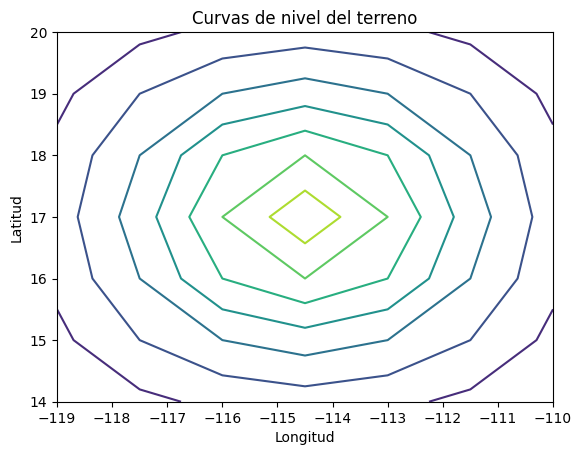

In [23]:
#Vamos a graficar

plt.contour(Lon,Lat,Z) # La función necesita los valores del eje x, ejex y los datos para hacer los contornos

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel del terreno")

plt.show() #¿Qué observan?

#### <font color="darkblue"> **Personalización**

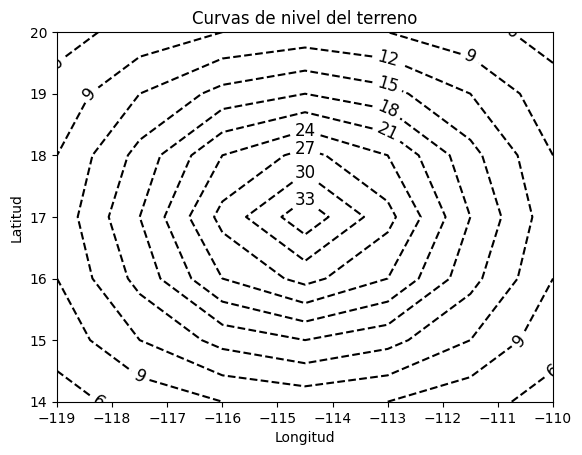

In [26]:
#Ejemplo 1

cont = plt.contour(Lon,Lat,Z,
                   levels=10,  #Cuántas isolíneas se dibujan
                   colors="black", #Color de las isolíneas, también puedo definir diferentes colores en una lista
                   linewidths=1.5,  # Grosor
                   linestyles="dashed", #Estilo de la línea, por default "solid"
                  )

#plt.clabel() nos permite etiquetar líneas de contorno

plt.clabel(cont,  #Gráfico al que queremos colocar las etiquetas
           inline=True, #Posición de las etiquetas
           fontsize=12  #Tamaño
          )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel del terreno")

plt.show()

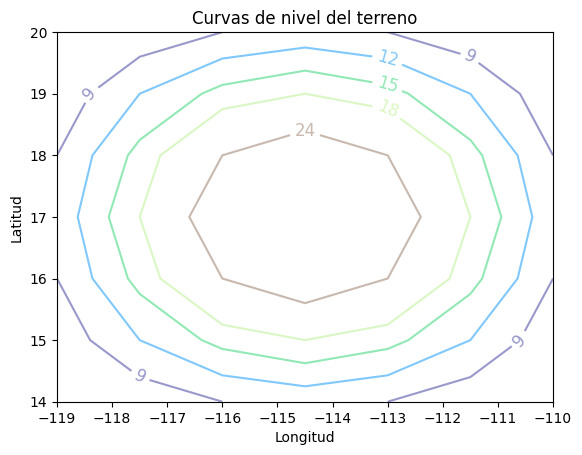

In [27]:
#Ejemplo 2

cont = plt.contour(Lon,Lat,Z,
                   levels=[9,12,15,18,24,30], #También puedo definir una lista con los levels que quiero (incrementando los valores)
                   cmap="terrain", #También puedo definir un colomar para que cada línea tenga un color diferente
                   linewidths=1.5,  
                   linestyles="solid", 
                   alpha=0.5  #Transparencia
                  )

#plt.clabel() nos permite etiquetar líneas de contorno

plt.clabel(cont,  #Gráfico al que queremos colocar las etiquetas
           inline=True, #Posición de las etiquetas
           fontsize=12  #Tamaño
          )

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel del terreno")

plt.show()

#### <font color="darkorange"> **Ejemplo 2: `plt.contourf()`**

<https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html>

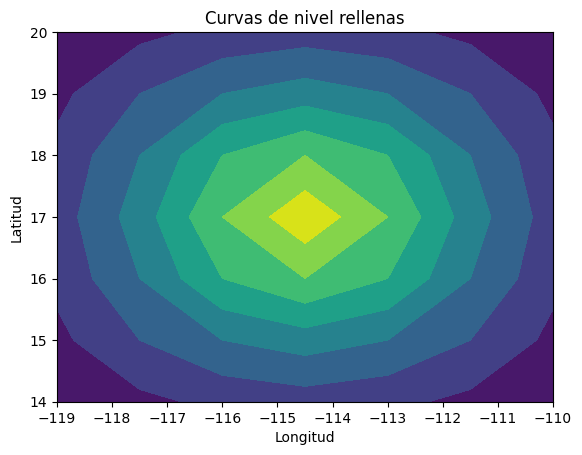

In [28]:
#Vamos a graficar

plt.contourf(Lon,Lat,Z) # La función necesita los valores del eje x, ejex y los datos para hacer los contornos

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel rellenas")

plt.show() #¿Qué observan?

#### <font color="darkblue"> **Personalización**

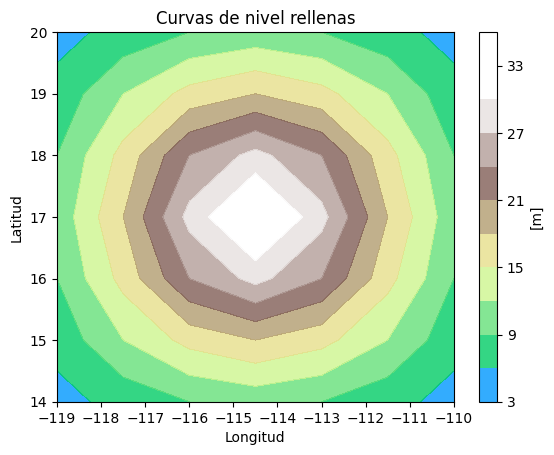

In [29]:
#Ejemplo 1

plt.contourf(Lon,Lat,Z,
                   levels=10, #También puedo definir una lista con los levels que quiero (incrementando los valores)
                   cmap="terrain", #También puedo definir un colomar para que cada línea tenga un color diferente   
                   alpha=0.8,  #Transparencia
                  vmin=0, #Límite inferior del colorbar
                  vmax=30 #Límite superior del color bar
            )

#Ya que es contorno rellenado, podemos agregar el colorbar
plt.colorbar(label="[m]")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel rellenas")

plt.show()

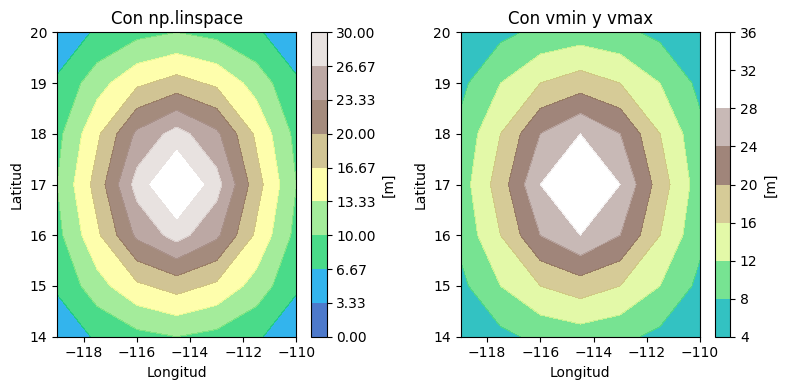

In [33]:
#Ejemplo 2: Para que puedas modificar los rangos del colorbar, los intervalos deben de estar definidos con ayuda de
#np.linspace() y quitar vmin y vmax. 

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)  #Permite gráficar múltiples páneles (,filas,columnas, posición)

niveles = np.linspace(0,30,10)


plt.contourf(Lon,Lat,Z,
                   levels=niveles, #También puedo definir una lista con los levels que quiero (incrementando los valores)
                   cmap="terrain", #También puedo definir un colomar para que cada línea tenga un color diferente   
                   alpha=0.8,  #Transparencia
                 
            )

#Ya que es contorno rellenado, podemos agregar el colorbar
plt.colorbar(label="[m]")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Con np.linspace")

#Otra manera de hacerlo es evitando definir los levels y dejando vmin y vmax
plt.subplot(1,2,2)
niveles = np.linspace(0,30,10)


plt.contourf(Lon,Lat,Z,  
            cmap="terrain", #También puedo definir un colomar para que cada línea tenga un color diferente   
            alpha=0.8,  #Transparencia
            vmin=0,
            vmax=30
            )

#Ya que es contorno rellenado, podemos agregar el colorbar
plt.colorbar(label="[m]")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Con vmin y vmax")

plt.tight_layout()

#El show() debe de ir al final y solo una vez
plt.show()

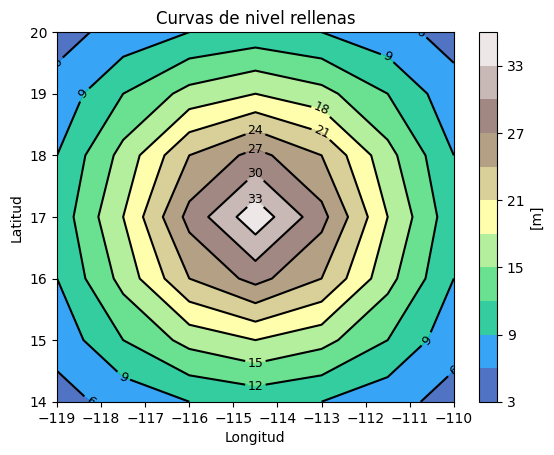

In [34]:
#Ejemplo 3: Combinando contour y countour f

#Contour
cont = plt.contour(Lon,Lat,Z,
                   levels=10,  
                   colors="black", 
                   linewidths=1.5,  
                   linestyles="solid"
                  )

#Contourf
plt.contourf(Lon,Lat,Z,
                   levels=10, 
                   cmap="terrain",    
                   alpha=0.8,  
            )


plt.clabel(cont,  #Gráfico al que queremos colocar las etiquetas
           inline=True, #Posición de las etiquetas
           fontsize=9  #Tamaño
          )

#Ya que es contorno rellenado, podemos agregar el colorbar
plt.colorbar(label="[m]")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Curvas de nivel rellenas")

plt.show()

### <font color="purple"> **Ejercicio 2: Campo de presión atmosférica**

A partir de los siguientes datos:
```python
# Coordenadas de la zona
x=np.linspace(-119,-110,6) #Longitud
y = np.linspace(14,20,6) #Latitud

presion = np.array([
[1018,1017,1016,1015,1014,1013],
[1019,1018,1016,1014,1013,1012],
[1020,1019,1017,1015,1013,1012],
[1021,1020,1018,1016,1014,1013],
[1022,1021,1019,1017,1015,1014],
[1023,1022,1020,1018,1016,1015]
])

```

**1. Grafica las isobaras (líneas de igual presión).**

**2. Grafica las isobaras con contornos rellenos.**

In [57]:
x=np.linspace(-119,-110,6) #Longitud
y = np.linspace(14,20,6) #Latitud

presion = np.array([
[1018,1017,1016,1015,1014,1013],
[1019,1018,1016,1014,1013,1012],
[1020,1019,1017,1015,1013,1012],
[1021,1020,1018,1016,1014,1013],
[1022,1021,1019,1017,1015,1014],
[1023,1022,1020,1018,1016,1015]
])


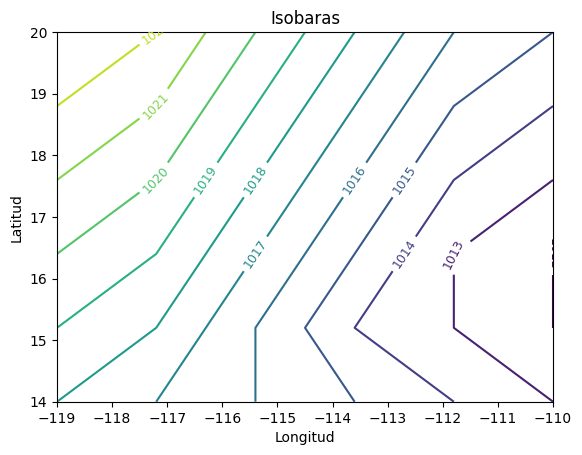

In [61]:
#Graficando las isobaras
#Contour
cont = plt.contour(x,y,presion,
                   levels=10,  
                   cmap="viridis", 
                   linewidths=1.5,  
                   linestyles="solid"
                  )

plt.clabel(cont,  #Gráfico al que queremos colocar las etiquetas
           inline=True, #Posición de las etiquetas
           fontsize=9  #Tamaño
          )


plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Isobaras")

plt.show()

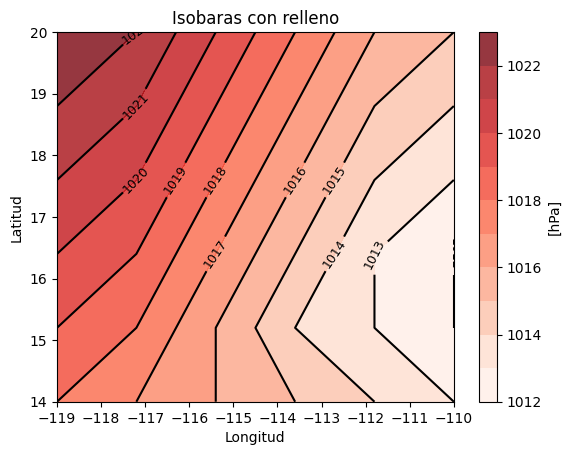

In [64]:
#Combinando contour y countour f

#Contour
cont = plt.contour(x,y,presion,
                   levels=10,  
                   colors="black", 
                   linewidths=1.5,  
                   linestyles="solid"
                  )

#Contourf
plt.contourf(x,y,presion,
                   levels=10, 
                   cmap="Reds",    
                   alpha=0.8,  
            )


plt.clabel(cont,  #Gráfico al que queremos colocar las etiquetas
           inline=True, #Posición de las etiquetas
           fontsize=9  #Tamaño
          )

#Ya que es contorno rellenado, podemos agregar el colorbar
plt.colorbar(label="[hPa]")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Isobaras con relleno")
plt.show()

------------------

# <font color="darkblue"> **Gráficos 3D**

<img src="3dim.png" width="850" style="margin-left: 100px;">



Los **gráficos tridimensionales (3D)** son una forma de visualización que permite representar datos utilizando tres dimensiones, lo que **facilita analizar la relación entre tres variables al mismo tiempo**. 
En este tipo de gráficos, dos variables suelen representarse en los ejes horizontales ($x$ e $y$), mientras que la tercera variable se representa en el eje vertical ($z$). 

Los gráficos 3D son especialmente útiles para visualizar superficies, relaciones complejas entre variables o estructuras espaciales que no se aprecian fácilmente en representaciones bidimensionales. *Entre los tipos más comunes se encuentran los gráficos de superficie, dispersión tridimensional y mallas, los cuales permiten explorar patrones y tendencias en los datos desde diferentes perspectivas* (<https://matplotlib.org/stable/gallery/mplot3d/index.html>). 

#### <font color="darkolivegreen"> **¿Cómo hacemos gráficas 3D?**
En Matplotlib, estos gráficos se pueden crear utilizando el módulo `mplot3d` (<https://matplotlib.org/stable/users/explain/toolkits/mplot3d.html>).


#### <font color="darkorange"> **Ejemplo 1: Gráfico de superficie (Topografía)**

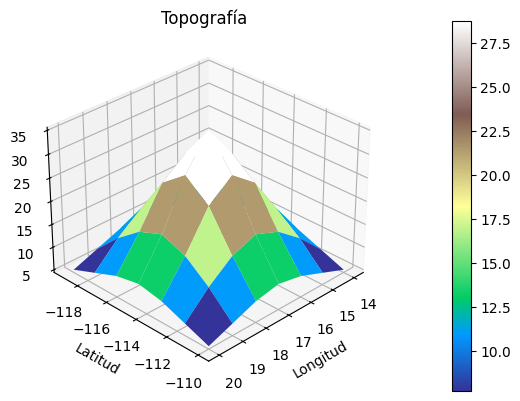

In [40]:
#Paso 1: Creamos un eje 3D

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

#Paso 2: Graficamos
#Para ello vamos a tomar los datos de Z y los valores de Lat y Lon 
topo=ax.plot_surface(Lat,Lon,Z,
                cmap="terrain"
                )

#Etiquetas
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_zlabel("Altura (m)")
plt.title("Topografía")

#Ángulo de visión
ax.view_init(elev=30, azim=45)

#Agregar barra de color
#cbar=fig.colorbar(topo)

#Separar la barra del gráfico
cbar = plt.colorbar(topo, pad=0.15)

plt.show()

#### <font color="darkorange"> **Ejemplo 2: Gráfico de línea 3D (Corriente oceánica)**

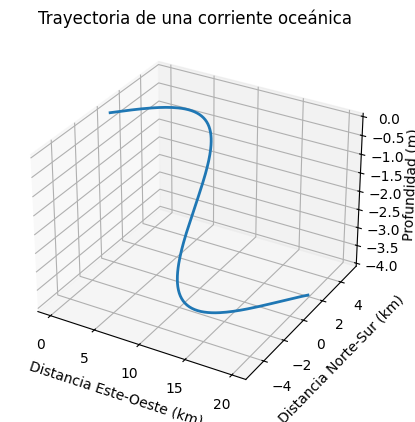

In [41]:
# Tiempo
t = np.linspace(0,20,200)

# Trayectoria simulada de una partícula en la corriente
x = t
y = 5*np.sin(t/3)
z = -0.2*t   # la partícula desciende ligeramente

#Definimos nuestro gráfico 3D
fig = plt.figure(figsize=(4,5))
ax = fig.add_subplot(111, projection='3d')

#Usamos .plot() para líneas
ax.plot(x,y,z, linewidth=2)

ax.set_xlabel("Distancia Este-Oeste (km)")
ax.set_ylabel("Distancia Norte-Sur (km)")
ax.set_zlabel("Profundidad (m)",labelpad=2)

ax.set_title("Trayectoria de una corriente oceánica")

fig.tight_layout()

plt.show()

**Para conocer más puedes visitar los siguientes sitios, donde encontraras diversos tutoriales**

* <https://www.delftstack.com/es/howto/matplotlib/matplotlib-3d-projection/>

* <https://www.geeksforgeeks.org/python/three-dimensional-plotting-in-python-using-matplotlib/>
  